In [1]:
# import icesat2db as isdb

# authenticator = isdb.EarthDataAuthenticator()
# authenticator.authenticate()

In [2]:
import icesat2db as isdb
import concurrent.futures

In [12]:
# Paths to configuration files
cfg = '../../scratch/data_config.yml'
geometry = '../../scratch/test.geojson'

# Initialize a parallel engine
concurrent_engine= concurrent.futures.ThreadPoolExecutor(max_workers=10)

# Initialize the IceSat2Processor and compute
with isdb.IceSat2Processor(
    config_file=cfg,
    geometry=geometry,
    start_date='2020-01-01',
    end_date='2020-12-31',
    earth_data_dir= 'C:/Users/s1803229/',
    parallel_engine=concurrent_engine,
) as processor:
    processor.compute(consolidate=True)

2026-04-23 17:00:24,300 - INFO - EarthData authentication setup is complete.
2026-04-23 17:00:24,372 - INFO - Successfully created TileDB array at ../../scratch/isdb_test/array_uri
2026-04-23 17:00:24,404 - INFO - Using user-provided parallel engine.
2026-04-23 17:00:25,015 - INFO - Intersection has 12 granule IDs across 1 products. Estimated download: 1.20 GB (0.00 TB). 
2026-04-23 17:00:25,033 - INFO - Starting IceSat2 granules processing...
2026-04-23 17:04:35,011 - INFO - Starting consolidation for ../../scratch/isdb_test/array_uri (type: spatial)
2026-04-23 17:04:44,775 - INFO - Consolidating array_meta...
2026-04-23 17:04:44,806 - INFO - Consolidating fragment_meta...
2026-04-23 17:04:44,823 - INFO - Consolidating commits...
2026-04-23 17:04:44,846 - INFO - Consolidation complete for ../../scratch/isdb_test/array_uri
2026-04-23 17:04:44,846 - INFO - IceSat2 granule processing completed successfully.
2026-04-23 17:04:44,846 - INFO - ThreadPoolExecutor has been shut down.


In [16]:
import geopandas as gpd
import icesat2db as isdb

# Create IceSat2Provider instance
provider = isdb.IceSat2Provider(storage_type='local',
                            local_path= "../../scratch/isdb_test/")

# Load region of interest
region_of_interest = gpd.read_file('../../scratch/test.geojson')

# Define the columns to query and additional parameters
vars_selected = ["photon_rate_te", "photon_rate_can_nr"]

# Profile the provider's `get_data` function
icesat2_data = provider.get_data(
    variables=vars_selected,
    query_type="bounding_box",
    geometry=region_of_interest,
    start_time="2018-01-01",
    end_time="2024-07-25",
    return_type='xarray'
)

In [37]:
provider.get_available_variables().index

Index(['asr', 'atlas_pa', 'beam_azimuth', 'beam_coelev', 'brightness_flag',
       'can_noise', 'canopy_h_metrics', 'canopy_h_metrics_abs',
       'canopy_openness', 'canopy_rh_conf', 'centroid_height',
       'cloud_flag_atm', 'cloud_fold_flag', 'delta_time', 'delta_time_beg',
       'delta_time_end', 'dem_flag', 'dem_h', 'dem_removal_flag', 'h_canopy',
       'h_canopy_20m', 'h_canopy_abs', 'h_canopy_quad', 'h_canopy_uncertainty',
       'h_dif_canopy', 'h_dif_ref', 'h_max_canopy', 'h_max_canopy_abs',
       'h_mean_canopy', 'h_mean_canopy_abs', 'h_median_canopy',
       'h_median_canopy_abs', 'h_min_canopy', 'h_min_canopy_abs',
       'h_te_best_fit', 'h_te_best_fit_20m', 'h_te_interp', 'h_te_max',
       'h_te_mean', 'h_te_median', 'h_te_min', 'h_te_mode', 'h_te_rh25',
       'h_te_skew', 'h_te_std', 'h_te_uncertainty', 'last_seg_extend',
       'latitude_20m', 'layer_flag', 'longitude_20m', 'msw_flag',
       'n_ca_photons', 'n_seg_ph', 'n_te_photons', 'n_toc_photons',
       'nig

In [24]:
icesat2_data.photon_rate_can_nr

<xarray.DataArray 'photon_rate_can_nr' (segment_id: 1291)> Size: 5kB
array([0.37168142, 0.23404256, 0.29464287, ..., 0.01492537, 0.32352942,
       0.21014492], dtype=float32)
Coordinates:
  * segment_id  (segment_id) object 10kB '193866234896485' ... '4547807727667...
    latitude    (segment_id) float64 10kB -15.83 -15.83 -15.83 ... -15.75 -15.75
    longitude   (segment_id) float64 10kB 30.38 30.38 30.38 ... 30.37 30.37
    time        (segment_id) datetime64[ns] 10kB 2020-12-25 ... 2020-01-29
Attributes:
    description:            Noise removed photon canopy rate within each 100 ...
    dtype:                  float32
    product_level:          unknown
    units:                  s^-1
    profile_label_name:     nan
    profile_labels:         nan
    profile_length:         nan
    subsegment_label_name:  nan
    subsegment_labels:      nan
    subsegment_length:      nan

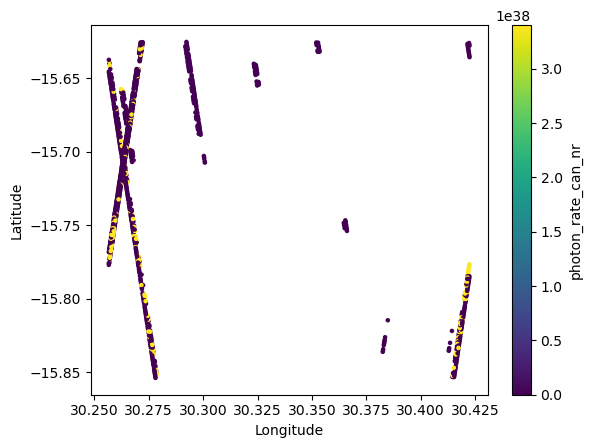

In [26]:
from matplotlib import pyplot as plt
da = icesat2_data.photon_rate_can_nr

plt.scatter(da.longitude, da.latitude, c=da.values, s=5)
plt.colorbar(label=da.name)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()